# ✈️ **AICE ASSOCIATE 제3회 실전모의고사**


## **여행 상품 추천 모델**
---
* **도메인** : 관광 / 여행 / e-커머스
* **목 표** : 사용자 프로필 및 행동 데이터를 활용한 개인화된 **여행 테마 추천 모델 개발**
* **'에듀-트래블(Edu-Travel)'** 은 업계 최대 규모의 여행 상품을 제공하고 있으나, 방대한 정보 속에서 사용자가 자신의 취향에 맞는 상품을 직접 찾는 데 큰 어려움을 겪고 있다.
* 수집된 사용자 데이터를 기반으로  ‘Historic City(역사 도시)’, ‘Beach Resort(해변 휴양)’, ‘Nature/Trekking(자연/트레킹)’ 등 개인화된 **여행 테마를 추천하는 모델을 개발**한다.
---

### **[데이터셋 소개]**
* traveler_profiles.csv: 여행객 프로필 정보
* traveler_booking_history.json: 여행객 행동 및 예약 기록

### **[컬럼 설명]**
**1. traveler_profiles.csv 파일 컬럼**
* **traveler_id**: 각 여행객을 식별하는 고유 ID
* **age**: 나이
* **annual_income**: 연간 수입
* **travel_style**: 선호하는 여행 스타일 (e.g., 'Balanced', 'Relaxing', 'Adventurous')
* **preferred_continent**: 선호하는 여행 대륙
* **last_login_date**: 마지막으로 플랫폼에 로그인한 날짜
* **device_ppi**: 주로 사용하는 기기의 PPI

**2. traveler_booking_history.json 파일 컬럼**
* **traveler_id**: 각 여행객을 식별하는 고유 ID
* **activity_score**: 플랫폼 내 활동 점수 (높을수록 활동적)
* **avg_travel_duration**: 평균 여행 기간 (일)
* **avg_companion_count**: 평균 동반 여행자 수
* **booking_channel**: 주로 사용하는 예약 채널 (e.g., 'Mobile App', 'Website', 'Agent')
* **support_inquiry_count**: 고객 지원팀에 문의한 횟수
* **recommended_theme**: 최종적으로 추천된 여행 테마 -> **목표 변수**

#### **1. 아래 지시사항에 따라 서로 다른 형식(CSV, JSON)의 두 데이터 파일을 불러와 하나의 데이터프레임으로 통합하고, 문제 유형을 판별하시오.**

---
* **대상 파일** : **`traveler_profiles.csv`**, **`traveler_booking_history.json`**
* **(1-1) 데이터 로드 및 병합**
    * **`pandas`** 라이브러리를 **`pd`** 별칭으로 임포트하세요.
    * **`traveler_profiles.csv`** 파일을 불러와 **`df_profile`** 에 저장하세요.
    * **`traveler_booking_history.json`** 파일을 불러와 **`df_history`** 에 저장하세요.
    * 두 데이터프레임을 **`traveler_id`** 컬럼을 기준으로 병합(Merge)하여 **`df`** 변수에 저장하세요.
    * 상위 5건의 데이터를 출력하세요.
* **(1-2) 타겟 변수의 클래스 개수 확인**
    * value_counts() 함수를 사용하여 타겟 변수(**`recommended_theme`**)의 클래스 개수를 확인하세요.
* **(1-3) 확인된 결과를 바탕으로 본 문제의 유형이 '회귀', '이진분류', '다중분류' 중 무엇인지 판별하여 기입하세요.**
---

In [3]:
import pandas as pd

df_profile = pd.read_csv('traveler_profiles.csv')
df_history = pd.read_json('traveler_booking_history.json')

df = pd.merge(df_profile, df_history, on='traveler_id')

df.head()

,traveler_id,age,annual_income,travel_style,preferred_continent,last_login_date,device_ppi,activity_score,avg_travel_duration,avg_companion_count,booking_channel,support_inquiry_count,recommended_theme
0,user_00001,59.0,17179,Balanced,Europe,2024-11-24,552,5.5,12,2,Agent,6,Historic City
1,user_00002,32.0,8729,Balanced,Europe,2024-08-22,210,6.1,7,4,Mobile App,10,Nature/Trekking
2,user_00003,43.0,13945,Relaxing,America,2024-02-20,497,3.3,2,0,Mobile App,3,Beach Resort
3,user_00004,25.0,10711,Relaxing,Asia,2024-08-08,428,4.9,10,1,Mobile App,7,Beach Resort
4,user_00005,NaN,10667,Balanced,Europe,2025-08-18,325,2.3,3,0,Mobile App,7,Historic City


In [4]:
df['recommended_theme'].value_counts()

recommended_theme
Historic City      1002
Beach Resort        874
Nature/Trekking     624
Name: count, dtype: int64

In [ ]:
다중분류

#### **2. 아래 지시사항에 따라 통합된 데이터프레임(`df`)의 범주형 데이터를 분석하고, 출력된 결과를 바탕으로 가장 빈도가 높은 항목의 개수를 기입하세요.**

---
* **대상 데이터프레임**: **`df`**
* **(2-1) 범주형 데이터 빈도 분석**
    * **`value_counts()`** 함수를 사용하여 **`travel_style`** 컬럼의 클래스별 데이터 개수(빈도수)를 출력하세요.
* **(2-2) 가장 많이 관측되는 여행 스타일의 데이터 개수를 기입하세요.**
---

In [6]:
df['travel_style'].value_counts()

travel_style
Relaxing       1072
Balanced        929
Adventurous     424
Name: count, dtype: int64

In [ ]:
Relaxing

#### **3. 아래 지시사항에 따라 특정 조건에 부합하는 데이터를 추출하고, 그 결과를 분석하여 출력하세요.**
---
* **대상 데이터프레임**: **`df`**
* **(3-1) 조건에 따른 데이터 필터링 및 정렬**
    * **`preferred_continent`** 가 **'Europe'** 이고, **`travel_style`** 이 **'Adventurous'** 인 여행객 데이터를 추출하세요.
    * 추출된 데이터를 연간 소득(**`annual_income`**)이 높은 순서(내림차순)로 정렬하여 상위 5개 데이터를 확인하세요.
* **(3-2) 연간 소득이 가장 많은 고객의 traveler_id를 찾아 기입하세요.**
---

In [7]:
cond1 = df['preferred_continent'] == 'Europe'
cond2 = df['travel_style'] == 'Adventurous'

cond = df[cond1 & cond2]

cond_sorted = cond.sort_values('annual_income', ascending=False)

cond_sorted.head()

,traveler_id,age,annual_income,travel_style,preferred_continent,last_login_date,device_ppi,activity_score,avg_travel_duration,avg_companion_count,booking_channel,support_inquiry_count,recommended_theme
2236,user_02237,39.0,46543,Adventurous,Europe,2025-02-05,217,8.4,14,0,Mobile App,2,Nature/Trekking
530,user_00531,24.0,42817,Adventurous,Europe,2025-04-22,363,7.2,4,2,Agent,8,Nature/Trekking
1050,user_01051,35.0,41245,Adventurous,Europe,2024-11-06,528,6.4,2,0,Website,2,Nature/Trekking
292,user_00293,18.0,39296,Adventurous,Europe,2024-05-17,328,6.7,11,1,Mobile App,10,Nature/Trekking
331,user_00332,21.0,38929,Adventurous,Europe,2025-02-05,516,9.3,2,1,Agent,1,Nature/Trekking


In [ ]:
# (3-2) 여기에 답안을 입력하세요(실행 불필요).

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### **4. 아래 지시사항에 따라 데이터의 분포를 시각화하고, 이를 바탕으로 이상치(Outlier)의 존재 여부를 분석하여 기입하세요.**
---
* **대상 데이터프레임**: **`df`**
* **(4-1) 연간 소득 데이터 시각화**
    * **`seaborn`** 라이브러리를 사용하세요.
    * **`boxplot()`** 을 사용하여 **`annual_income`** 컬럼의 데이터 분포를 시각화하세요.
* **(4-2) 이상치가 존재하면 **True**, 존재하지 않으면 **False**를 기입하세요.**
---

<Axes: ylabel='annual_income'>

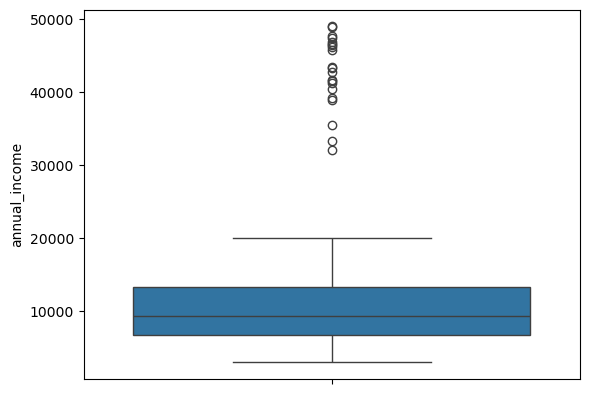

In [9]:
sns.boxplot(df, y='annual_income')

In [ ]:
True

#### **5. 아래 지시사항에 따라 결측치를 처리하고 데이터 타입을 변환하는 과정에서 발생한 코드의 오류를 정정하여 데이터 정제 작업을 완료하세요.**
---
* **대상 데이터프레임**: **`df`**
* **(5-1) 결측치 처리**
    * df를 복사하여 df_temp에 저장하세요.
    * 각 컬럼의 결측치 갯수를 출력하세요.
    * **`age`** 컬럼의 결측치는 해당 컬럼의 **중앙값(median)** 으로 채우세요.
    * **`travel_style`** 컬럼의 결측치는 해당 컬럼의 **최빈값(mode)** 의 첫 번째 값으로 채우세요.
    *  각 컬럼의 결측치 갯수를 출력하여, 결측치가 없음을 확인하세요.
* **(5-2) 문자열 치환 및 형 변환**
    * **`avg_companion_count`** 데이터 타입을 출력하세요.
    * **`avg_companion_count`** 컬럼 내 **'모름'** 데이터를 해당 컬럼의 **최빈값** 으로 치환하고, 데이터 타입을 **정수(int)** 로 변환하세요.
    * **`avg_companion_count`** 데이터 타입이 변환되었음을 확인하세요.
---

In [10]:
# (5-1) 여기에 코드의 오류를 정정하고 실행하세요.
df_temp = df.copy()
print('결측치 처리 전\n', df_temp.isnull().sum())

df_temp['age'] = df_temp['age'].fillna(df_temp['age'].median())
df_temp['travel_style'] = df_temp['travel_style'].fillna(df_temp['travel_style'].mode()[0])

print('결측치 처리 후\n', df_temp.isnull().sum())

결측치 처리 전
 traveler_id                0
age                      125
annual_income              0
travel_style              75
preferred_continent        0
last_login_date            0
device_ppi                 0
activity_score             0
avg_travel_duration        0
avg_companion_count        0
booking_channel            0
support_inquiry_count      0
recommended_theme          0
dtype: int64
결측치 처리 후
 traveler_id              0
age                      0
annual_income            0
travel_style             0
preferred_continent      0
last_login_date          0
device_ppi               0
activity_score           0
avg_travel_duration      0
avg_companion_count      0
booking_channel          0
support_inquiry_count    0
recommended_theme        0
dtype: int64


In [11]:
# (5-2) 여기에 코드의 오류를 정정하고 실행하세요.
print('형 변환 전\n', df_temp['avg_companion_count'].dtype)

mode_val = df_temp['avg_companion_count'].mode()[0]
df_temp['avg_companion_count'] = df_temp['avg_companion_count'].replace('모름', mode_val).astype('int')

print('형 변환 후\n', df_temp['avg_companion_count'].dtype)

형 변환 전
 object
형 변환 후
 int64


#### **6. 아래 지시사항에 따라 날짜 데이터를 가공하여 파생변수를 생성하고, 분석에 불필요한 데이터를 정리하세요.**
---
* **대상 데이터프레임**: **`df_temp`**
* **(6-1) 경과일 파생변수 생성**
    * **`last_login_date`** 컬럼을 날짜 형식으로 변환하기 위해 적절한 함수(**`<#6-1>`**)를 사용하세요.
    * 기준일('2025-09-01')과 로그인 날짜의 차이에서 **'일(day)'** 단위의 정수값만 추출하기 위한 속성(**`<#6-2>`**)을 사용하세요.
* **(6-2) 데이터프레임 정리**
    * 분석에 사용이 완료된 **`last_login_date`** 와 **`traveler_id`** 컬럼을 삭제하기 위한 함수(**`<#6-3>`**)를 사용하세요.
    * **`df_drop`** 변수에 저장하세요.
    * 상위 5건 데이터를 출력하세요.
---

In [12]:
# (코드 셀) 지시사항에 따라 코드의 빈칸을 채우고 실행하세요.
# 1. 날짜 타입 변환 및 경과일 계산
df_temp['last_login_date'] = pd.to_datetime(df_temp['last_login_date'])
target_date = pd.to_datetime('2025-09-01')

# 로그인 후 경과일(days) 추출
df_temp['days_since_last_login'] = (target_date - df_temp['last_login_date']).dt.days

# 2. 불필요 컬럼 삭제 및 새 변수 저장
df_drop = df_temp.drop(columns=['last_login_date', 'traveler_id'])

# 결과 확인
df_drop.head()

,age,annual_income,travel_style,preferred_continent,device_ppi,activity_score,avg_travel_duration,avg_companion_count,booking_channel,support_inquiry_count,recommended_theme,days_since_last_login
0,59.0,17179,Balanced,Europe,552,5.5,12,2,Agent,6,Historic City,281
1,32.0,8729,Balanced,Europe,210,6.1,7,4,Mobile App,10,Nature/Trekking,375
2,43.0,13945,Relaxing,America,497,3.3,2,0,Mobile App,3,Beach Resort,559
3,25.0,10711,Relaxing,Asia,428,4.9,10,1,Mobile App,7,Beach Resort,389
4,41.0,10667,Balanced,Europe,325,2.3,3,0,Mobile App,7,Historic City,14


In [ ]:
# (6-1) 여기에 <#6-3>의 답안을 입력하세요(실행 불필요).

In [ ]:
# (6-2) 여기에 <#6-3>의 답안을 입력하세요(실행 불필요).

In [ ]:
# (6-3) 여기에 <#6-3>의 답안을 입력하세요(실행 불필요).

#### **7. 아래 지시사항에 따라 수치형 데이터의 이상치를 IQR(Interquartile Range) rule을 사용하여 처리하세오.**
---
* **대상 데이터프레임** : **`df_drop`**
* **(7-1) 이상치 경계값 계산하고 대체**
    * **`annual_income`** 컬럼에 대해 1사분위수(Q1)와 3사분위수(Q3)를 구하고, 이를 이용해 **IQR(Interquartile Range)** 을 계산하세요.
    * 계산된 IQR을 바탕으로 상향 경계값(**Upper Bound**)을 출력하세요.
    * **`annual_income`** 컬럼의 데이터 중 상향 경계값을 초과하는 이상치를 모두 해당 **상향 경계값**으로 대체하세요.
* **(7-2) 처리가 완료된 후, **`annual_income`** 컬럼의 최댓값(max)을 기입하세요.**
---

In [14]:
Q1 = df_drop['annual_income'].quantile(0.25)
Q3 = df_drop['annual_income'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + (1.5 * IQR)
print(upper_bound)
cond7_1 = df_drop['annual_income'] > upper_bound

df_drop.loc[cond7_1, 'annual_income'] = upper_bound

23097.0


In [15]:
df_drop['annual_income'].max()

23097

#### **8. 아래 지시사항에 따라 타깃 변수와 피처(Feature) 데이터를 머신러닝 모델 학습이 가능한 수치형 데이터로 인코딩하세요.**
---
* **대상 데이터프레임**: **`df_drop`**
* **타깃 변수 라벨 인코딩**
    * **`sklearn.preprocessing`** 에서 **`LabelEncoder`** 를 임포트하세요.
    * **`LabelEncoder`** 객체를 생성하여 **`target_encoder`** 변수에 저장하세요.
    * **`target_encoder`** 를 사용하여 타깃 변수인 **`recommended_theme`** 컬럼을 수치로 변환하고 해당 컬럼에 다시 저장하세요.
* **피처(Feature) 라벨 인코딩**
    * **`LabelEncoder`** 객체를 새로 생성하여 **`feature_encoder`** 변수에 저장하세요.
    * **`travel_style`** 컬럼을 **`LabelEncoder`**를 사용하여 수치로 변환하고 해당 컬럼에 다시 저장하세요.
* **피처(Feature) 원-핫 인코딩**
    * **`preferred_continent`** 와 **`booking_channel`** 컬럼에 대해 원-핫 인코딩을 수행하세요.
    * 이때, 다중공선성 방지를 위해 첫 번째 카테고리를 제외하는 옵션(**`drop_first=True`**)을 적용하고 결과를 **`df_final`** 에 저장하세요.
    * 상위 5개의 데이터를 출력하세요.
---

In [17]:
# (코드 셀) 지시사항에 따라 코드의 빈칸을 채우고 실행하세요.
from sklearn.preprocessing import LabelEncoder

# 1. 라벨 인코딩 수행
target_encoder = LabelEncoder()
df_drop['recommended_theme'] = target_encoder.fit_transform(df_drop['recommended_theme'])

feature_encoder = LabelEncoder()
df_drop['travel_style'] = feature_encoder.fit_transform(df_drop['travel_style'])

# 2. 원-핫 인코딩 수행 
# 특정 컬럼들만 지정하여 인코딩 수행
df_final = pd.get_dummies(df_drop, columns=['preferred_continent', 'booking_channel'], drop_first=True)

# 3. 최종 데이터 구조 확인
df_final.head()

,age,annual_income,travel_style,device_ppi,activity_score,avg_travel_duration,avg_companion_count,support_inquiry_count,recommended_theme,days_since_last_login,preferred_continent_Asia,preferred_continent_Europe,preferred_continent_Oceania,booking_channel_Mobile App,booking_channel_Website
0,59.0,17179,1,552,5.5,12,2,6,1,281,False,True,False,False,False
1,32.0,8729,1,210,6.1,7,4,10,2,375,False,True,False,True,False
2,43.0,13945,2,497,3.3,2,0,3,0,559,False,False,False,True,False
3,25.0,10711,2,428,4.9,10,1,7,0,389,True,False,False,True,False
4,41.0,10667,1,325,2.3,3,0,7,1,14,False,True,False,True,False


In [ ]:
# (8-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (8-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (8-3) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (8-4) 여기에 답안을 입력하세요(실행 불필요).

#### **9. 아래 지시사항에 따라 데이터를 피처(X)와 타겟(y)으로 분리하고, 학습 및 테스트 데이터셋으로 분할한 뒤 피처 스케일링을 수행하세요.**
---
* **대상 데이터프레임**: **`df_final`**
* **피처(X)와 타겟(y) 분리**
    * 타겟 변수를 제외한 나머지 모든 컬럼을 피처 변수 **`X`** 에 저장하세요.
    * 타겟 변수는 **`y`** 에 저장하세요.
* **학습 및 테스트 데이터셋 분할**
    * scikit-learn의 train_test_split 함수를 활용하세요.
    * 변수 저장: 훈련 데이터는 X_train, y_train에, 검증 데이터는 X_valid, y_valid에 저장하세요.
    * 분할 비율은 **7:3**, 난수 시드는 42 로 설정하세요.
    * 다중 분류 문제이므로 타깃 변수의 비율을 유지하기 위해 옵션을 반드시 추가하세요.
* **피처 스케일링**
    * sklearn.preprocessing에서 StandardScaler 함수를 import하세요.
    * StandardScaler를 사용하여 scaler 변수에 저장하세요.
    * 학습 데이터(**`X_train`**): 데이터를 학습하고 변환하세요.
    * 검증 데이터(**`X_valid`**): 학습 데이터의 기준을 그대로 사용하여 변환만 수행하세요.
---

In [19]:
# (코드 셀) 지시사항에 따라 코드의 빈칸을 채우고 실행하세요.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_final.drop('recommended_theme', axis=1)
y = df_final['recommended_theme']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print("X_train_scaled 형상:", X_train_scaled.shape)
print("X_valid_scaled 형상:", X_valid_scaled.shape)

X_train_scaled 형상: (1750, 14)
X_valid_scaled 형상: (750, 14)


In [ ]:
# (9-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (9-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (9-3) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (9-4) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (9-5) 여기에 답안을 입력하세요(실행 불필요).

#### **10. 고객의 여행 취향과 정보를 바탕으로 가장 적합한 여행 테마(recommended_theme)를 예측하는 머신러닝 모델을 만들려고 합니다. DecisionTree, RandomForest, GradientBoosting은 트리 구조를 통해 독립변수 공간을 반복적으로 분할하는 모형으로서, 분류와 회귀 분석에 모두 사용될 수 있습니다.**
---
* **대상 데이터**: **`X_train_scaled`**, **`y_train`**, **`X_valid_scaled`**, **`y_valid`**
* **(10-1) DecisionTree 모델의 하이퍼파라미터를 아래와 같이 구성하고, 변수에 저장하세요.**
    * 트리의 최대 깊이(`max_depth`): 5
    * 노드를 분할하기 위한 최소한의 샘플 데이터 수(`min_samples_split`): 3
    * 난수 시드(`random_state`): 42
    * Decision Tree 모델을 **`dt`** 변수에 저장하세요.
    * 앞서 분리한 훈련 데이터셋으로 **`fit`** 함수를 사용해 학습시키세요.
* **(10-2) RandomForest 모델의 하이퍼파라미터를 아래와 같이 구성하고, 변수에 저장하세요.**
    * 트리의 최대 깊이(`max_depth`): 5
    * 노드를 분할하기 위한 최소한의 샘플 데이터 수(`min_samples_split`): 3
    * 난수 시드(`random_state`): 42
    * Random Forest 모델을 **`rf`** 변수에 저장하세요.
    * 앞서 분리한 훈련 데이터셋으로 **`fit`** 함수를 사용해 학습시키세요.
* **(10-3) GradientBoosting 모델의 하이퍼파라미터를 아래와 같이 구성하고, 변수에 저장하세요.**
    * 트리의 최대 깊이(`max_depth`): 5
    * 학습률(`learning_rate`): 0.1
    * 난수 시드(`random_state`): 42
    * Gradient Boosting 모델을 **`gb`** 변수에 저장하세요.
    * 앞서 분리한 훈련데이터셋으로 **`fit`** 함수를 사용해 학습시키세요.
* **(10-4) 학습된 3가지 모델의 성능을 비교하여 최적의 모델을 선정하세요.**
    * 각 모델(`dt`, `rf`, `gb`)을 사용하여 검증 데이터(`X_valid_scaled`)에 대한 예측값을 생성하세요.
    * **`f1_score` (average='macro')** 를 계산하여 각 모델의 성능을 출력하세요.
---

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

dt = DecisionTreeClassifier(max_depth=5, min_samples_split=3, random_state=42) 
rf = RandomForestClassifier(max_depth=5, min_samples_split=3, random_state=42)
gb = GradientBoostingClassifier(max_depth=5, learning_rate=0.1, random_state=42)

dt.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
gb.fit(X_train_scaled, y_train)

from sklearn.metrics import f1_score

dt_pred = dt.predict(X_valid_scaled)
rf_pred = rf.predict(X_valid_scaled)
gb_pred = gb.predict(X_valid_scaled)

dt_f1 = f1_score(dt_pred, y_valid, average='macro')
rf_f1 = f1_score(rf_pred, y_valid, average='macro')
gb_f1 = f1_score(gb_pred, y_valid, average='macro')

print(dt_f1, rf_f1, gb_f1)

0.9065386395548556 0.9120512846349628 0.908598807915746


In [ ]:
# (10-4) 여기에 답안코드를 작성하고 실행하세요.

#### **11. 모델의 해석력과 개선 방향을 이해하기 위해 RandomForest 모델의 변수 중요도를 파악하려고 합니다.**
---
* **대상 데이터 및 모델**: **`X.columns`**, **`rf`** (문제 10번에서 학습한 모델)
* **(11-1) 변수 중요도 파악 및 시각화 오류 정정**
    * 아래 가이드에 따라 변수 중요도를 파악하는 과정에서 발생한 코드의 오류를 정정하세요.
    * 변수 중요도 점수(`feature_importances_`)와 변수 이름을 매핑하여 **`DataFrame`** 을 만드세요.
    * 중요도 점수를 기준으로 **내림차순 정렬** 하고 **상위 10개(top 10)** 만 선정하세요.
    * 선정된 상위 10개 변수의 중요도를 **막대 그래프(barplot)** 로 시각화하세요.
* **(11-2) 출력된 그래프에서 가장 높은 중요도를 보이는 변수명을 쓰세요.**
---

<Axes: xlabel='importance', ylabel='feature'>

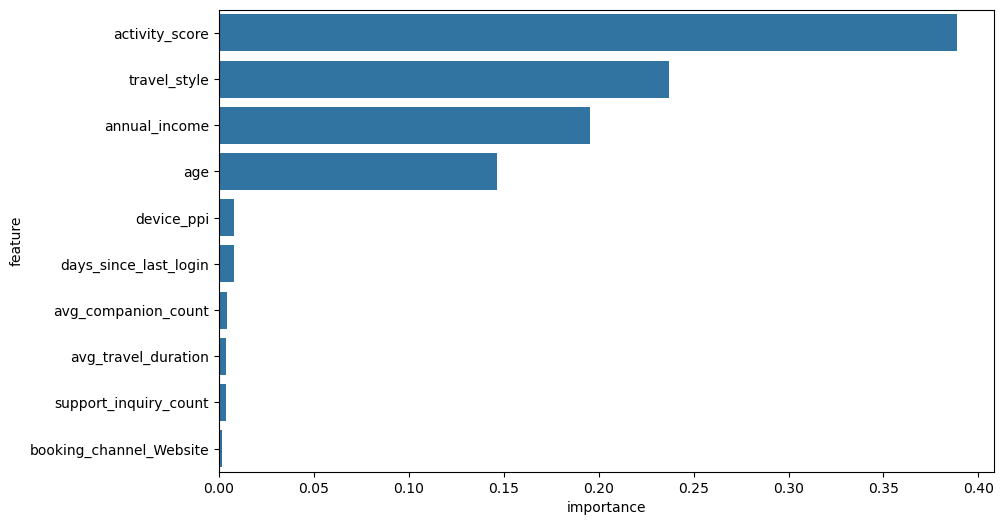

In [22]:
# (11-1) 여기에 코드의 오류를 정정하고 실행하세요.
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
top10_features = feature_importance.sort_values(by='importance', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=top10_features)

In [ ]:
A

#### **12. 구축된 추천 모델의 신뢰성을 확보하기 위해 다양한 평가지표를 활용하여 모델의 성능을 종합적으로 분석하려고 합니다. 분류 모델의 성능을 평가할 때 정확도(Accuracy)만으로는 클래스별 예측 성능을 구체적으로 파악하기 어렵습니다. 정밀도(Precision), 재현율(Recall), F1-score를 포함한 종합적인 지표를 한눈에 확인할 수 있는 보고서를 생성하는 것이 중요합니다.**
---
* **대상 데이터 및 모델**: **`X_valid_scaled`**, **`y_valid`**, **`rf`** (문제 10번에서 학습한 RandomForest 모델)
* **(12-1) 모델의 예측 및 종합 성능 지표 출력**
    * **`sklearn.metrics`** 패키지에서 **`classification_report`** 함수를 임포트하세요.
    * 앞서 학습시킨 최적 모델(**`rf`**)을 사용하여 검증 데이터(**`X_valid_scaled`**)에 대한 예측값을 생성하고 **`y_pred`** 변수에 저장하세요.
    * **`classification_report`** 함수를 사용하여 실제값(**`y_valid`**)과 예측값(**`y_pred`**)을 비교하고, 그 결과를 **`print()`** 함수로 출력하세요.
* **(12-2) 세 가지 클래스(0, 1, 2) 중 모델이 가장 완벽하게 예측하고 있는(F1-score 기준) 클래스 번호를 기입하세요.**
---

In [23]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_valid_scaled)
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       262
           1       0.89      0.87      0.88       301
           2       0.98      0.99      0.99       187

    accuracy                           0.90       750
   macro avg       0.91      0.91      0.91       750
weighted avg       0.90      0.90      0.90       750



In [ ]:
2

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(0)

#### **13. 아래 지시사항에 따라 여행 테마를 예측하기 위한 딥러닝 모델을 설계하고, 아래 토폴로지 다이어그램과 가이드를 참고하여 모델링하고 학습을 수행하세요.**
---
* **대상 데이터**: **`X_train_scaled`**, **`y_train`**, **`X_valid_scaled`**, **`y_valid`**
* **모델 설계 및 조기 종료 설정**
    * 제공된 토폴로지에 따라 히든 레이어를 구성하세요.
    * 마지막 아웃풋 레이어의 노드 수는 타깃 클래스 개수(3개)로 설정하고, activation 함수는 **'softmax'** 를 사용하세요.
    * **`EarlyStopping`** 함수를 사용하여 9번의 epoch 동안 모니터링 지표(**'val_loss'**)가 향상되지 않을 경우 훈련을 중지하도록 설정하고 **`estop`** 변수에 저장하세요.
* **모델 컴파일 및 학습**
    * **`optimizer='adam'`**, **`metrics=['accuracy']`**, 타깃이 정수형이므로 **`loss='sparse_categorical_crossentropy'`** 로 지정하여 모델을 컴파일하세요.
    * 다음 조건에 따라 모델을 학습하고 학습정보는 **`history`** 변수에 저장하세요.
        * **`batch_size`**: 32
        * **`epochs`**: 100
        * **`callbacks`**: 위에서 설정한 **`estop`** 변수를 리스트 형태로 입력하세요.
    * 안내된 내용 외 별도의 파라미터는 입력하지 마세요.
---

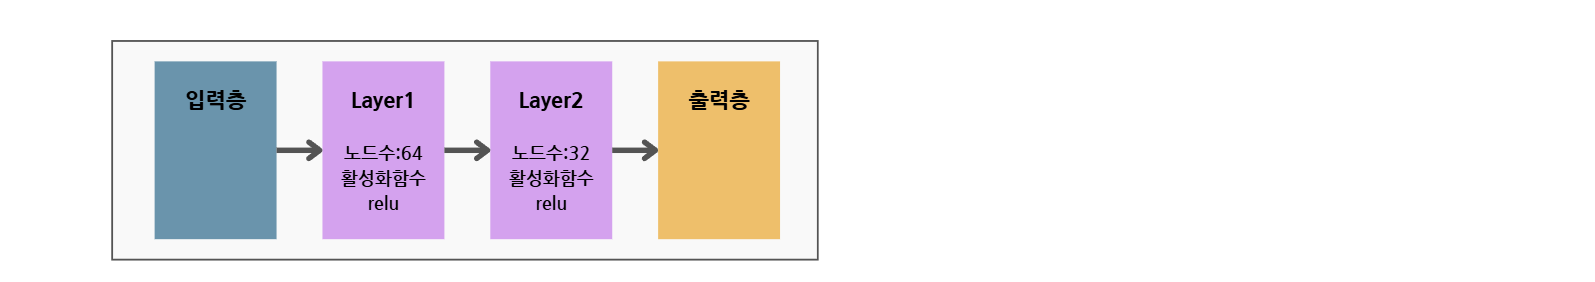

In [25]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
dl_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='sigmoid')
])

estop = EarlyStopping(monitor='val_loss', patience=9)
dl_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history = dl_model.fit(X_train_scaled, y_train,
                       validation_data=(X_valid_scaled, y_valid),
                       epochs=100,
                       batch_size=32,
                       callbacks=[estop])

C:\Users\kun99\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6017 - loss: 0.8960 - val_accuracy: 0.7653 - val_loss: 0.6726
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8143 - loss: 0.5234 - val_accuracy: 0.8213 - val_loss: 0.4281
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8509 - loss: 0.3768 - val_accuracy: 0.8387 - val_loss: 0.3674
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8623 - loss: 0.3301 - val_accuracy: 0.8440 - val_loss: 0.3476
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8691 - loss: 0.3077 - val_accuracy: 0.8400 - val_loss: 0.3382
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8777 - loss: 0.2938 - val_accuracy: 0.8493 - val_loss: 0.3337
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8794 - loss: 0.2836 - val_accuracy: 0.8507 - val_loss: 0.3308
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8823 - loss: 0.2756 - val_accuracy: 0.8493 - 

In [ ]:
# (13-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (13-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (13-3) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (13-4) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (13-5) 여기에 답안을 입력하세요(실행 불필요).

#### **14. 딥러닝 모델의 학습 과정(History)을 시각화하고, 학습 곡선을 분석하여 모델의 상태를 진단하세요.**

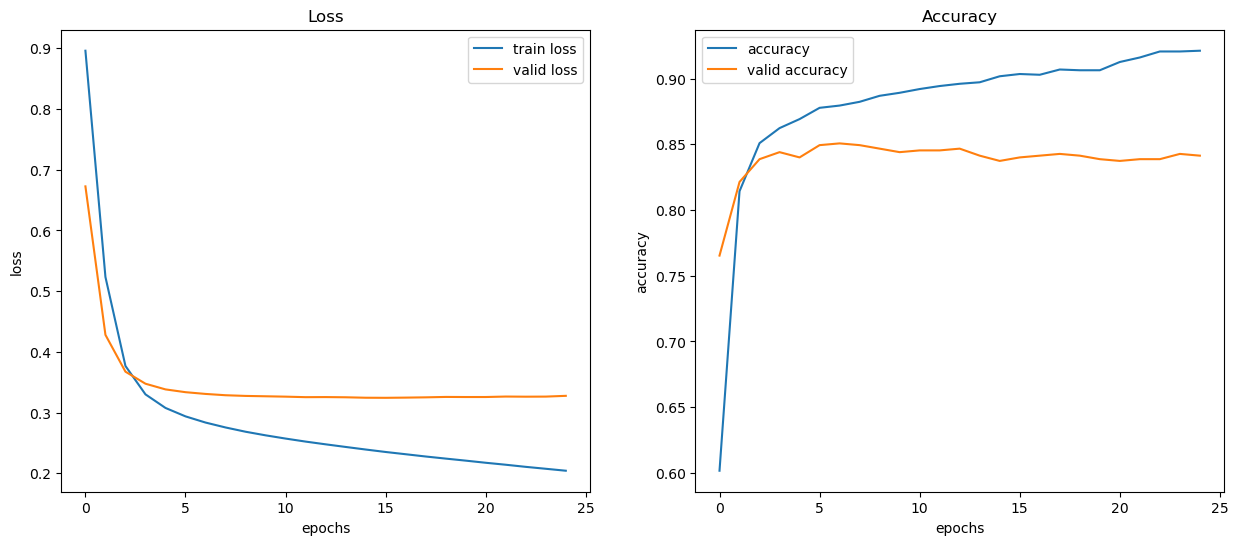

In [26]:
#아래의 시각화 코드를 실행하여 결과를 분석하시오.
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='valid loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='valid accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()

plt.show()

**실행 결과의 그래프에 대한 해석과 가장 적절한 대응 방법으로 짝지어진 번호를 기입하세요.**

(1)
- **해석**: 훈련 손실(Training Loss)과 검증 손실(Validation Loss)이 모두 감소하고 있으므로, 모델이 안정적으로 학습되고 있다.
- **대응**: 학습률(learning rate)을 높여 더 빠르게 최적점에 도달하도록 한다.

(2)
- **해석**: 검증 정확도(Validation Accuracy)가 훈련 정확도(Training Accuracy)보다 높으므로, 모델이 일반화 성능을 잘 확보했다.
- **대응**: 모델의 복잡도를 낮추기 위해 레이어(layer)나 노드(node)의 수를 줄인다.

(3)
- **해석**: 훈련 정확도(Training Accuracy)는 계속 상승하지만 검증 정확도(Validation Accuracy)는 특정 시점부터 정체되거나 하락하는 **과적합(Overfitting)** 현상이 발생했다.
- **대응**: `EarlyStopping` 콜백을 사용하여 검증 성능이 더 이상 개선되지 않을 때 학습을 조기 종료시킨다.

(4)
- **해석**: 훈련 데이터의 양이 부족하여 발생하는 **과소적합(Underfitting)** 현상이므로, 모델이 패턴을 충분히 학습하지 못했다.
- **대응**: `Dropout` 레이어를 추가하거나 L1/L2 규제(regularization)를 적용하여 모델의 일반화 성능을 높인다.

In [ ]:
# (14) 여기에 답안을 입력하세요(실행 불필요).